In [1]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [19]:
np.random.seed(42)
nam = 6*np.random.rand(100,1) -3
yd =  0.5 * nam**2 +1.5*nam +2+np.random.randn(100,1)
data = {
    "x":nam.ravel(),
    "y":yd.ravel()
}

df = pd.DataFrame(data)

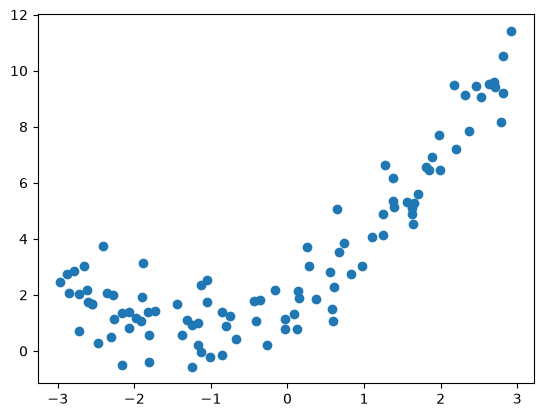

In [20]:
plt.scatter(df["x"],df["y"])


In [22]:
x = df.drop(columns="y")
y = df["y"]

In [27]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [30]:
# Training data shape
print(X_train.shape)
print(y_train.shape)

# Testing data shape
print(X_test.shape)
print(y_test.shape)

(75, 1)
(75,)
(25, 1)
(25,)


In [31]:
# Implementing linear regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [ ]:
# trained lr model
lr.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.28]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['x']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.301
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [33]:
from sklearn.metrics import r2_score
score = r2_score(y_test,lr.predict(X_test))
print(score)

0.6517667218574366


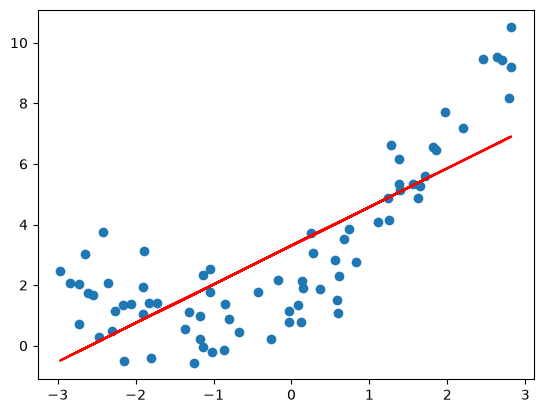

In [45]:
plt.scatter(X_train,y_train)
plt.plot(X_train,lr.predict(X_train),"r")
plt.show()

In [58]:
# Applying polynomial features
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2,include_bias=True)

In [59]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

In [60]:
X_train_poly

array([[ 1.00000000e+00, -1.89957294e+00,  3.60837736e+00],
       [ 1.00000000e+00, -2.26777059e+00,  5.14278345e+00],
       [ 1.00000000e+00,  1.36396976e-01,  1.86041351e-02],
       [ 1.00000000e+00,  1.24843547e+00,  1.55859111e+00],
       [ 1.00000000e+00, -2.96686730e+00,  8.80230156e+00],
       [ 1.00000000e+00,  2.81945911e+00,  7.94934969e+00],
       [ 1.00000000e+00,  1.20408127e-01,  1.44981171e-02],
       [ 1.00000000e+00, -1.04890007e+00,  1.10019135e+00],
       [ 1.00000000e+00,  5.54487413e-01,  3.07456291e-01],
       [ 1.00000000e+00,  3.67663185e-01,  1.35176218e-01],
       [ 1.00000000e+00, -2.06403288e+00,  4.26023172e+00],
       [ 1.00000000e+00, -2.15445465e+00,  4.64167484e+00],
       [ 1.00000000e+00,  2.56176499e-01,  6.56263986e-02],
       [ 1.00000000e+00,  1.85038409e+00,  3.42392128e+00],
       [ 1.00000000e+00, -1.17454654e+00,  1.37955958e+00],
       [ 1.00000000e+00, -1.89087327e+00,  3.57540171e+00],
       [ 1.00000000e+00,  2.79379220e+00

In [61]:
X_test_poly

array([[ 1.        , -2.6186499 ,  6.85732729],
       [ 1.        ,  2.3689641 ,  5.61199092],
       [ 1.        ,  1.63346862,  2.66821972],
       [ 1.        ,  0.97513371,  0.95088574],
       [ 1.        , -1.44732011,  2.0947355 ],
       [ 1.        , -0.35908504,  0.12894206],
       [ 1.        , -1.24713211,  1.5553385 ],
       [ 1.        ,  2.17862056,  4.74638752],
       [ 1.        , -2.87649303,  8.27421218],
       [ 1.        , -0.75275929,  0.56664654],
       [ 1.        , -0.40832989,  0.1667333 ],
       [ 1.        ,  0.64526911,  0.41637223],
       [ 1.        ,  1.89276857,  3.58257286],
       [ 1.        ,  2.69331322,  7.25393612],
       [ 1.        , -2.28243452,  5.20950736],
       [ 1.        , -2.06388816,  4.25963433],
       [ 1.        ,  1.62762208,  2.64915364],
       [ 1.        , -2.55573209,  6.53176651],
       [ 1.        ,  1.99465584,  3.97865194],
       [ 1.        , -1.97685526,  3.90795671],
       [ 1.        ,  2.53124541,  6.407

In [ ]:
poly_lr = LinearRegression()
poly_lr.fit(X_train_poly,y_train)

y_pred = poly_lr.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.94382980737886


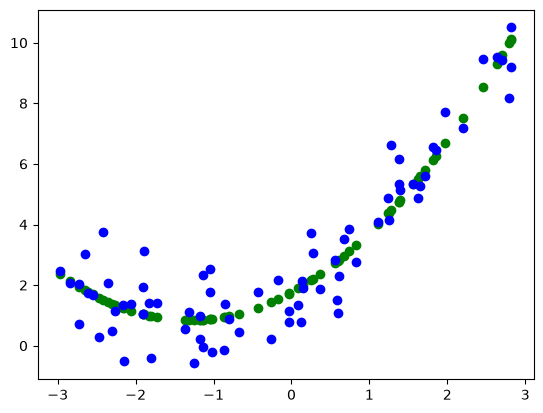

In [68]:
plt.scatter(X_train,poly_lr.predict(X_train_poly),color = "green")
plt.scatter(X_train,y_train,color = "b")

In [80]:
# Predicting new input

new = np.linspace(-3,3, 100).reshape(100, 1)

p_poly = poly.transform(new)
pred_p = poly_lr.predict(p_poly)


c:\Users\Anuj Kumar\Desktop\Machine Learning\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


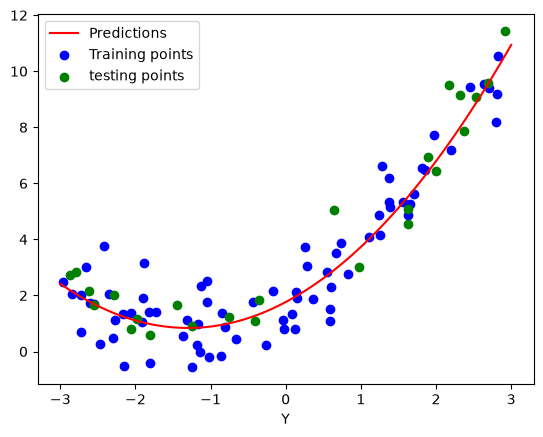

In [88]:
plt.plot(new,pred_p,color="red",label ="Predictions")
plt.scatter(X_train,y_train,color="b",label = "Training points")
plt.scatter(X_test,y_test,color='g',label="testing points")

plt.xlabel("X")
plt.xlabel("Y")
plt.legend()
plt.show()